Epoch [1/10], Loss: 1.1059
Epoch [2/10], Loss: 1.0738
Epoch [3/10], Loss: 0.8923
Epoch [4/10], Loss: 1.2364
Epoch [5/10], Loss: 0.7410
Epoch [6/10], Loss: 0.8505
Epoch [7/10], Loss: 0.8962
Epoch [8/10], Loss: 0.9044
Epoch [9/10], Loss: 0.8957
Epoch [10/10], Loss: 0.8847
Model saved as 'unet_satellite.pth'


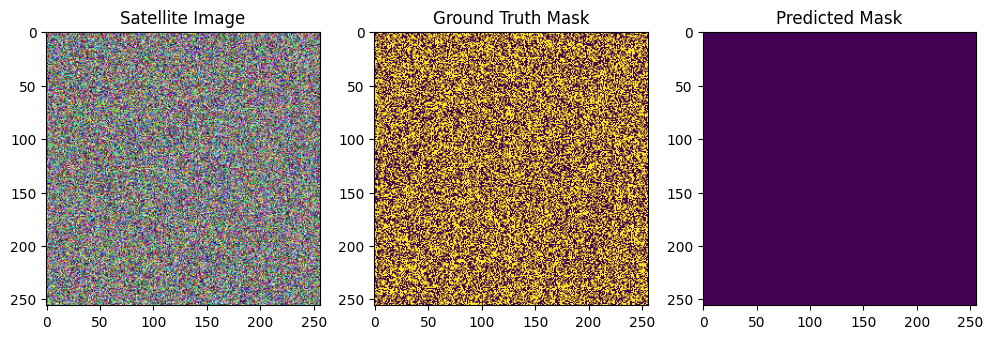

In [1]:
# ==========================================
# Image Segmentation using UNet
# ==========================================
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Dataset Class
# ==========================================
class SatelliteDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = os.listdir(image_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])

        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path).convert("L"))

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # Transform to Tensor
        image = transforms.ToTensor()(image)
        # Masks for CrossEntropyLoss must be Long tensors (integers)
        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask

# ==========================================
# UNet Model
# ==========================================
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_classes):
        super(UNet, self).__init__()
        self.dconv_down1 = DoubleConv(3, 64)
        self.dconv_down2 = DoubleConv(64, 128)
        self.dconv_down3 = DoubleConv(128, 256)
        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dconv_up2 = DoubleConv(256 + 128, 128)
        self.dconv_up1 = DoubleConv(128 + 64, 64)
        self.conv_last = nn.Conv2d(64, n_classes, 1)

    def forward(self, x):
        # Encoder
        conv1 = self.dconv_down1(x)
        x = self.maxpool(conv1)
        conv2 = self.dconv_down2(x)
        x = self.maxpool(conv2)
        x = self.dconv_down3(x)

        # Decoder
        x = self.upsample(x)
        x = torch.cat([x, conv2], dim=1)
        x = self.dconv_up2(x)
        x = self.upsample(x)
        x = torch.cat([x, conv1], dim=1)
        x = self.dconv_up1(x)
        x = self.conv_last(x)
        return x

# ==========================================
# Hyperparameters
# ==========================================
batch_size = 4
lr = 1e-3
num_epochs = 10
n_classes = 3

# ==========================================
# Load Dataset
# ==========================================
# Create dummy directories for images and masks to prevent FileNotFoundError
# In a real scenario, you would upload your dataset to these paths or mount Google Drive.
os.makedirs("images/train", exist_ok=True)
os.makedirs("masks/train", exist_ok=True)

# Create dummy image and mask files to avoid empty dataset error
# Creating a dummy RGB image (256x256x3) and a dummy mask (256x256)
dummy_image = Image.fromarray(np.random.randint(0, 255, (256, 256, 3), dtype=np.uint8))
dummy_mask = Image.fromarray(np.random.randint(0, n_classes - 1, (256, 256), dtype=np.uint8))

dummy_image.save("images/train/dummy_image.png")
dummy_mask.save("masks/train/dummy_image.png")

train_dataset = SatelliteDataset("images/train", "masks/train")
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# ==========================================
# Device, Model, Loss, Optimizer
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(n_classes=n_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# ==========================================
# Training Loop
# ==========================================
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for imgs, masks in train_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(train_loader):.4f}")

# ==========================================
# Save Model
# ==========================================
torch.save(model.state_dict(), "unet_satellite.pth")
print("Model saved as 'unet_satellite.pth'")

# ==========================================
# Visualize Predictions
# ==========================================
model.eval()
# Get the first sample from the dataset
sample_img, sample_mask = train_dataset[0]

with torch.no_grad():
    # Unsqueeze to add batch dimension (1, C, H, W)
    pred = model(sample_img.unsqueeze(0).to(device))
    # Get the class with max probability and move to CPU numpy
    pred_mask = torch.argmax(pred.squeeze(0), dim=0).cpu().numpy()

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
# Permute needed because matplotlib expects (H, W, C) but Torch gives (C, H, W)
plt.imshow(sample_img.permute(1, 2, 0))
plt.title("Satellite Image")

plt.subplot(1, 3, 2)
plt.imshow(sample_mask)
plt.title("Ground Truth Mask")

plt.subplot(1, 3, 3)
plt.imshow(pred_mask)
plt.title("Predicted Mask")
plt.show()

# ==========================================
# Save Predicted Masks
# ==========================================
# (Code logic for saving masks would continue here)